# Predição da Resistência à Compressão de Concretos Utilizando Redes Neurais MLP: Aprendizado de Máquina e Otimização

Autor: André de Araújo Caetano

Github do Projeto: [Github](https://github.com/andre-aracaetano/study-of-mlp-and-genetic-algorithm-with-a-cement-dataset)

## Bibliotecas

In [27]:
import kagglehub # Opcional para donwload do dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools, random, time
import xgboost as xgb
import shap

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 67
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 1. Preparação do dataset

Download do dataset diretamente do Kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vinayakshanawad/cement-manufacturing-concrete-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.1k/11.1k [00:00<00:00, 7.56MB/s]

Extracting files...
Path to dataset files: C:\Users\andre\.cache\kagglehub\datasets\vinayakshanawad\cement-manufacturing-concrete-dataset\versions\1


In [2]:
df = pd.read_csv("concrete.csv")
print(df.shape)
print(df.columns.tolist())
display(df)

(1030, 9)
['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age', 'strength']


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29
...,...,...,...,...,...,...,...,...,...
1025,135.0,0.0,166.0,180.0,10.0,961.0,805.0,28,13.29
1026,531.3,0.0,0.0,141.8,28.2,852.1,893.7,3,41.30
1027,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1028,342.0,38.0,0.0,228.0,0.0,932.0,670.0,270,55.06


Para o problema que estou trabalhando, eu quero utilizar os compostos que compoem o concreto para prever sua "strength", que neste caso significa capacidade de compressão.

O significado das colunas é:

- **Cimento:** É o aglomerante principal do concreto, responsável por unir os materiais. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Escória de alto-forno:** Um subproduto da indústria siderúrgica que pode ser usado como adição ao concreto para melhorar suas propriedades. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Cinzas volantes:** Resíduo da queima de carvão em usinas termelétricas, utilizado no concreto para melhorar sua durabilidade. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Água:** Essencial para a hidratação do cimento e a mistura dos materiais. Medida em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Superplastificante:** Aditivo que melhora a trabalhabilidade do concreto sem comprometer sua resistência. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Agregado graúdo:** Pedras ou britas que compõem o concreto, fornecendo resistência mecânica. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Agregado miúdo:** Areia ou pó de pedra que preenche os vazios entre os agregados graúdos, melhorando a trabalhabilidade. Medido em quilogramas por metro cúbico de mistura ($\mathrm{kg/m^3}$).

- **Idade:** Tempo, em dias, desde a mistura do concreto. Varia de 1 a 365 dias.

- **Resistência à compressão do concreto:** Medida em Megapascal ($\mathrm{MPa}$), indica a capacidade do concreto de suportar cargas de compressão.

É interessante notar que, com excessão do nosso Target e da Idade, todas as outras colunas são dadas em $\mathrm{kg/m^3}$, inclusive a água.

Nenhuma limpeza é necessária pois este dataset já está bem estabelecido, sem valores nan ou valores que divergem do esperado.

In [3]:
TARGET = "strength"

Podemos plotar um gráfico de correlação inicial para entender melhor como as features estão organizadas e o balanceamento dos dados do Target.

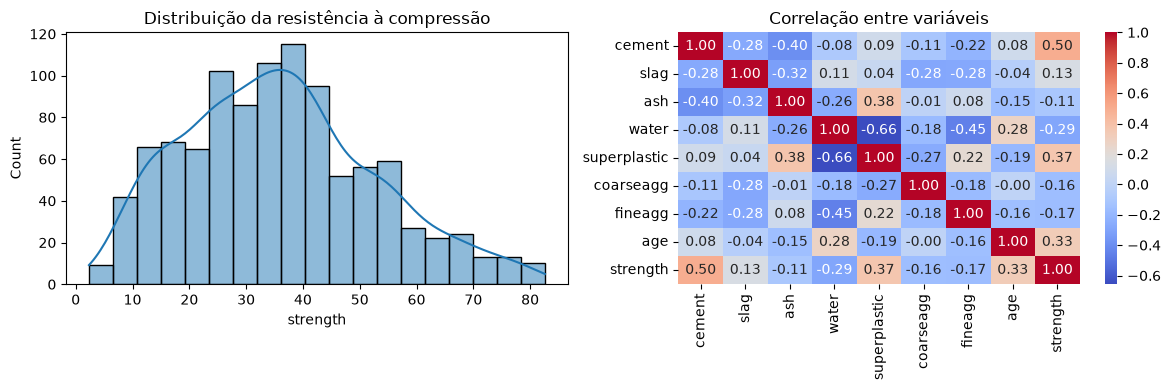

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], kde=True, ax=axes[0])
axes[0].set_title("Distribuição da resistência à compressão")

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlação entre variáveis")
plt.tight_layout()
plt.show()

O dataset faz sentido do ponto de vista das ciências dos materiais. A força tem grande influência do cimento, da adição do plastificante e do tempo de "cura" do material, que é a "age". Além disso, a água apresenta uma correlação contrária, o que também faz sentido, a relação água/cimento é bem definida pela diluição do material que irá solidificar pela quantidade de água, diminuindo a resistência a compressão.

### Split de treino e teste com normalização (85/15)

In [5]:
X = df.drop(columns=[TARGET]).values.astype(np.float32)
y = df[TARGET].values.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

scaler_X = StandardScaler().fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Também vale normalizar o alvo, desnormalizamos na hora de avaliar.
scaler_y = StandardScaler().fit(y_train)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print("Treino:", X_train_scaled.shape, " Teste:", X_test_scaled.shape)

Treino: (875, 8)  Teste: (155, 8)


## 2. Construção da MLP

In [6]:
class ConcreteDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class MLP(nn.Module):
    def __init__(self, in_features, hidden=(64, 32), dropout=0.15, activation=nn.ReLU):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden:
            layers += [nn.Linear(prev, h), activation(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

Também optei pela utilização de Early Stopping, que é uma técnica de treinamento utilizada para evitar o overfitting. Ela funciona monitorando o desempenho do modelo em um conjunto de validação separado durante o treinamento. Quando a métrica de validação deixa de melhorar por um número definido de iterações (parâmetro de paciência), o ciclo de treinamento é interrompido prematuramente.

In [7]:
MAX_EPOCHS = 300 
PATIENCE = 20 # Paciência do Early Stopping (quantas épocas sem melhora antes de parar)
LEARNING_RATE = 1e-3




def train_model(model, train_loader, val_loader, max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LEARNING_RATE, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(criterion(model(xb), yb).item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f"Época {epoch:3d} | val_loss (MSE, escala normalizada): {val_loss:.4f}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping na época {epoch}")
            break

    model.load_state_dict(best_state)
    return model, best_val_loss

### 2.1 Validação Cruzada

Cada fold treina um modelo do zero e mede o RMSE na parte de validação (na escala original, já desnormalizada). Isso dá uma estimativa mais robusta do desempenho do que um único split.

In [8]:
def run_kfold(X, y, n_splits=5, hidden=(64, 32), dropout=0.15, batch_size=32):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_rmses = []

    for fold, (tr_idx, val_idx) in enumerate(kfold.split(X)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        train_loader = DataLoader(ConcreteDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(ConcreteDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

        model = MLP(in_features=X.shape[1], hidden=hidden, dropout=dropout).to(device)
        model, _ = train_model(model, train_loader, val_loader)

        model.eval()
        with torch.no_grad():
            preds_scaled = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()

        # Desnormaliza para calcular RMSE em MPa (unidade real)
        preds = scaler_y.inverse_transform(preds_scaled)
        y_val_real = scaler_y.inverse_transform(y_val)

        rmse = np.sqrt(mean_squared_error(y_val_real, preds))
        fold_rmses.append(rmse)
        print(f"Fold {fold+1}/{n_splits} — RMSE: {rmse:.3f} MPa")

    print(f"\nRMSE médio (K-Fold): {np.mean(fold_rmses):.3f} ± {np.std(fold_rmses):.3f} MPa")
    return fold_rmses

fold_rmses = run_kfold(X_train_scaled, y_train_scaled, n_splits=5)

Fold 1/5 — RMSE: 4.681 MPa
Fold 2/5 — RMSE: 4.526 MPa
Fold 3/5 — RMSE: 5.392 MPa
Fold 4/5 — RMSE: 5.547 MPa
Fold 5/5 — RMSE: 5.404 MPa

RMSE médio (K-Fold): 5.110 ± 0.420 MPa


### 2.2 Modelo Final

In [9]:
# Fatia interna do treino só para o early stopping do modelo final
X_fit, X_val_final, y_fit, y_val_final = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=SEED
)

train_loader = DataLoader(ConcreteDataset(X_fit, y_fit), batch_size=32, shuffle=True)
val_loader = DataLoader(ConcreteDataset(X_val_final, y_val_final), batch_size=32, shuffle=False)

final_model = MLP(in_features=X_train_scaled.shape[1], hidden=(64, 32), dropout=0.15).to(device)
final_model, _ = train_model(final_model, train_loader, val_loader, verbose=True)

final_model.eval()
with torch.no_grad():
    test_preds_scaled = final_model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()

test_preds = scaler_y.inverse_transform(test_preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test_real, test_preds))
mae = mean_absolute_error(y_test_real, test_preds)
r2 = r2_score(y_test_real, test_preds)

print(f"RMSE: {rmse:.3f} MPa")
print(f"MAE:  {mae:.3f} MPa")
print(f"R²:   {r2:.3f}")

Época   0 | val_loss (MSE, escala normalizada): 0.5695
Época  20 | val_loss (MSE, escala normalizada): 0.1398
Época  40 | val_loss (MSE, escala normalizada): 0.1352
Época  60 | val_loss (MSE, escala normalizada): 0.0917
Época  80 | val_loss (MSE, escala normalizada): 0.0895
Época 100 | val_loss (MSE, escala normalizada): 0.0818
Early stopping na época 105
RMSE: 4.982 MPa
MAE:  3.646 MPa
R²:   0.911


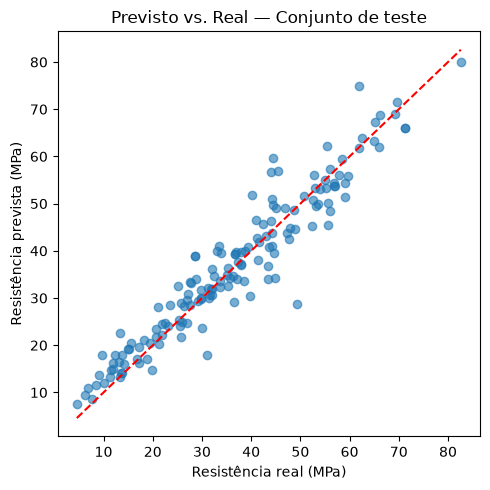

In [10]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test_real, test_preds, alpha=0.6)
lims = [min(y_test_real.min(), test_preds.min()), max(y_test_real.max(), test_preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Resistência real (MPa)")
plt.ylabel("Resistência prevista (MPa)")
plt.title("Previsto vs. Real — Conjunto de teste")
plt.tight_layout()
plt.show()

Okay, com essa baseline estabelecida posso começar a varias os hiperparâmetros buscando achar aquele em que meu RMSE é o mínimo possível. Vale ressaltar que, como o objetivo do projeto também visa aplicar Algoritmo genético e SHAP não vou me estender tanto na melhora do modelo.

### 2.3 Melhoria da MLP v1

In [11]:
def evaluate_config(hidden, dropout, lr, max_epochs, activation, n_splits=5):
    """K-Fold rápido (3 folds) só pra ranquear configurações na busca."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, val_idx in kfold.split(X_train_scaled):
        X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train_scaled[tr_idx], y_train_scaled[val_idx]

        train_loader = DataLoader(ConcreteDataset(X_tr, y_tr), batch_size=32, shuffle=True)
        val_loader = DataLoader(ConcreteDataset(X_val, y_val), batch_size=32, shuffle=False)

        model = MLP(in_features=X_train_scaled.shape[1], hidden=hidden,
                    dropout=dropout, activation=activation).to(device)
        model, _ = train_model(model, train_loader, val_loader,
                                max_epochs=max_epochs, patience=40, lr=lr)

        model.eval()
        with torch.no_grad():
            preds_scaled = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()
        preds = scaler_y.inverse_transform(preds_scaled)
        y_val_real = scaler_y.inverse_transform(y_val)
        rmses.append(np.sqrt(mean_squared_error(y_val_real, preds)))

    return np.mean(rmses)

In [12]:
random.seed(SEED)

param_space = {
    "activation_name": ["ReLU"],
    "hidden": [(64,), (64,32), (128, 128), (256,), (256, 256, 256, 256)],
    "dropout": [0.15, 0.3, 0.5],
    "lr": [0.001, 0.01, 0.05],
    "max_epochs": [100, 150, 200],
}
activation_map = {"ReLU": nn.ReLU}

all_combos = list(itertools.product(*param_space.values()))
N_TRIALS = 30  # amostra aleatória em vez das 216 combinações completas

sampled = random.sample(all_combos, N_TRIALS)

results = []
for i, (act_name, hidden, dropout, lr, max_epochs) in enumerate(sampled):
    t0 = time.time()
    rmse = evaluate_config(hidden, dropout, lr, max_epochs, activation_map[act_name])
    print(f"[{i+1:2d}/{N_TRIALS}] act={act_name:5s} hidden={str(hidden):22s} "
          f"dropout={dropout:<4} lr={lr:<6} epochs={max_epochs:<3} "
          f"-> RMSE={rmse:.3f} MPa ({time.time()-t0:.1f}s)")
    results.append({"activation": act_name, "hidden": hidden, "dropout": dropout,
                     "lr": lr, "max_epochs": max_epochs, "rmse": rmse})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

[ 1/30] act=ReLU  hidden=(64,)                  dropout=0.5  lr=0.001  epochs=150 -> RMSE=6.410 MPa (20.7s)
[ 2/30] act=ReLU  hidden=(64, 32)               dropout=0.15 lr=0.001  epochs=200 -> RMSE=4.941 MPa (30.8s)
[ 3/30] act=ReLU  hidden=(256,)                 dropout=0.5  lr=0.01   epochs=200 -> RMSE=5.464 MPa (18.4s)
[ 4/30] act=ReLU  hidden=(256, 256, 256, 256)   dropout=0.3  lr=0.001  epochs=200 -> RMSE=4.793 MPa (73.6s)
[ 5/30] act=ReLU  hidden=(256,)                 dropout=0.5  lr=0.05   epochs=150 -> RMSE=7.073 MPa (8.8s)
[ 6/30] act=ReLU  hidden=(128, 128)             dropout=0.3  lr=0.01   epochs=200 -> RMSE=5.104 MPa (25.2s)
[ 7/30] act=ReLU  hidden=(256, 256, 256, 256)   dropout=0.15 lr=0.001  epochs=150 -> RMSE=4.690 MPa (61.4s)
[ 8/30] act=ReLU  hidden=(256, 256, 256, 256)   dropout=0.3  lr=0.05   epochs=150 -> RMSE=15.672 MPa (35.0s)
[ 9/30] act=ReLU  hidden=(128, 128)             dropout=0.5  lr=0.05   epochs=150 -> RMSE=11.202 MPa (10.2s)
[10/30] act=ReLU  hidden=(6

,activation,hidden,dropout,lr,max_epochs,rmse
0,ReLU,"(128, 128)",0.15,0.001,200,4.667695
1,ReLU,"(256, 256, 256, 256)",0.15,0.001,150,4.690247
2,ReLU,"(256, 256, 256, 256)",0.30,0.001,200,4.792971
3,ReLU,"(64, 32)",0.15,0.001,200,4.941140
4,ReLU,"(256,)",0.15,0.010,150,4.968625
5,ReLU,"(64, 32)",0.15,0.010,150,4.976644
6,ReLU,"(256, 256, 256, 256)",0.30,0.001,100,5.033055
7,ReLU,"(256,)",0.30,0.010,200,5.056010
8,ReLU,"(64,)",0.15,0.010,200,5.097147
9,ReLU,"(128, 128)",0.30,0.010,200,5.104060


In [13]:
best = results_df.iloc[0]
print("Melhor configuração encontrada na busca:")
print(best)

best_hidden = best["hidden"]
best_dropout = best["dropout"]
best_lr = best["lr"]
best_epochs = best["max_epochs"]
best_activation = activation_map[best["activation"]]

Melhor configuração encontrada na busca:
activation          ReLU
hidden        (128, 128)
dropout             0.15
lr                 0.001
max_epochs           200
rmse            4.667695
Name: 0, dtype: object


In [14]:
# --- Confirmação final: 5-fold completo + avaliação no teste, com a melhor config ---
final_rmse_kfold = evaluate_config(best_hidden, best_dropout, best_lr, best_epochs,
                                    best_activation, n_splits=5)
print(f"RMSE médio (5-fold) com a melhor config: {final_rmse_kfold:.3f} MPa")

X_fit, X_val_final, y_fit, y_val_final = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=SEED
)
train_loader = DataLoader(ConcreteDataset(X_fit, y_fit), batch_size=32, shuffle=True)
val_loader = DataLoader(ConcreteDataset(X_val_final, y_val_final), batch_size=32, shuffle=False)

final_model = MLP(in_features=X_train_scaled.shape[1], hidden=best_hidden,
                   dropout=best_dropout, activation=best_activation).to(device)
final_model, _ = train_model(final_model, train_loader, val_loader,
                              max_epochs=best_epochs, patience=40, lr=best_lr, verbose=True)

final_model.eval()
with torch.no_grad():
    test_preds_scaled = final_model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()
test_preds = scaler_y.inverse_transform(test_preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test_real, test_preds))
mae = mean_absolute_error(y_test_real, test_preds)
r2 = r2_score(y_test_real, test_preds)
print(f"RMSE: {rmse:.3f} MPa | MAE: {mae:.3f} MPa | R²: {r2:.3f}")

RMSE médio (5-fold) com a melhor config: 4.563 MPa
Época   0 | val_loss (MSE, escala normalizada): 0.5174
Época  20 | val_loss (MSE, escala normalizada): 0.1075
Época  40 | val_loss (MSE, escala normalizada): 0.0872
Época  60 | val_loss (MSE, escala normalizada): 0.0855
Época  80 | val_loss (MSE, escala normalizada): 0.0838
Época 100 | val_loss (MSE, escala normalizada): 0.0894
Época 120 | val_loss (MSE, escala normalizada): 0.0756
Época 140 | val_loss (MSE, escala normalizada): 0.0694
Época 160 | val_loss (MSE, escala normalizada): 0.0777
Época 180 | val_loss (MSE, escala normalizada): 0.0619
RMSE: 4.909 MPa | MAE: 3.347 MPa | R²: 0.914


Com base nessa melhor arquitetura, que está bem próximo ao meu baseline, eu rodei novamente a busca de hiperparametros incrementando mais variações em torno destes parametros.

### Melhorias da MLP v2

In [15]:
def evaluate_config(hidden, dropout, lr, max_epochs, activation, n_splits=5):
    """K-Fold rápido (3 folds) só pra ranquear configurações na busca."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, val_idx in kfold.split(X_train_scaled):
        X_tr, X_val = X_train_scaled[tr_idx], X_train_scaled[val_idx]
        y_tr, y_val = y_train_scaled[tr_idx], y_train_scaled[val_idx]

        train_loader = DataLoader(ConcreteDataset(X_tr, y_tr), batch_size=32, shuffle=True)
        val_loader = DataLoader(ConcreteDataset(X_val, y_val), batch_size=32, shuffle=False)

        model = MLP(in_features=X_train_scaled.shape[1], hidden=hidden,
                    dropout=dropout, activation=activation).to(device)
        model, _ = train_model(model, train_loader, val_loader,
                                max_epochs=max_epochs, patience=40, lr=lr)

        model.eval()
        with torch.no_grad():
            preds_scaled = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()
        preds = scaler_y.inverse_transform(preds_scaled)
        y_val_real = scaler_y.inverse_transform(y_val)
        rmses.append(np.sqrt(mean_squared_error(y_val_real, preds)))

    return np.mean(rmses)

In [16]:
random.seed(SEED)

param_space = {
    "activation_name": ["ReLU", "GELU", "LeakyReLU", "ELU"],
    "hidden": [(64, 32), (128, 128), (256,), (256, 256, 256, 256)],
    "dropout": [0.15, 0.3],
    "lr": [0.001, 0.01],
    "max_epochs": [150, 200],
}
activation_map = {
    "ReLU": nn.ReLU,
    "GELU": nn.GELU,
    "LeakyReLU": nn.LeakyReLU,
    "ELU": nn.ELU,
}

all_combos = list(itertools.product(*param_space.values()))
N_TRIALS = 28  # amostra aleatória

sampled = random.sample(all_combos, N_TRIALS)

results = []
for i, (act_name, hidden, dropout, lr, max_epochs) in enumerate(sampled):
    t0 = time.time()
    rmse = evaluate_config(hidden, dropout, lr, max_epochs, activation_map[act_name])
    print(f"[{i+1:2d}/{N_TRIALS}] act={act_name:5s} hidden={str(hidden):22s} "
          f"dropout={dropout:<4} lr={lr:<6} epochs={max_epochs:<3} "
          f"-> RMSE={rmse:.3f} MPa ({time.time()-t0:.1f}s)")
    results.append({"activation": act_name, "hidden": hidden, "dropout": dropout,
                     "lr": lr, "max_epochs": max_epochs, "rmse": rmse})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

[ 1/28] act=ReLU  hidden=(256,)                 dropout=0.15 lr=0.01   epochs=200 -> RMSE=5.016 MPa (18.4s)
[ 2/28] act=ReLU  hidden=(128, 128)             dropout=0.3  lr=0.01   epochs=150 -> RMSE=4.950 MPa (26.5s)
[ 3/28] act=ELU   hidden=(64, 32)               dropout=0.15 lr=0.01   epochs=150 -> RMSE=5.240 MPa (24.1s)
[ 4/28] act=GELU  hidden=(256,)                 dropout=0.3  lr=0.001  epochs=150 -> RMSE=6.175 MPa (25.3s)
[ 5/28] act=GELU  hidden=(256, 256, 256, 256)   dropout=0.15 lr=0.01   epochs=200 -> RMSE=5.483 MPa (34.9s)
[ 6/28] act=GELU  hidden=(256,)                 dropout=0.3  lr=0.001  epochs=200 -> RMSE=5.977 MPa (36.3s)
[ 7/28] act=GELU  hidden=(64, 32)               dropout=0.15 lr=0.01   epochs=150 -> RMSE=4.891 MPa (26.0s)
[ 8/28] act=ELU   hidden=(256, 256, 256, 256)   dropout=0.15 lr=0.001  epochs=150 -> RMSE=4.992 MPa (63.2s)
[ 9/28] act=LeakyReLU hidden=(128, 128)             dropout=0.3  lr=0.001  epochs=150 -> RMSE=4.939 MPa (30.1s)
[10/28] act=GELU  hidden

,activation,hidden,dropout,lr,max_epochs,rmse
0,GELU,"(64, 32)",0.15,0.010,200,4.883140
1,GELU,"(64, 32)",0.15,0.010,150,4.890770
2,LeakyReLU,"(256,)",0.15,0.010,150,4.907901
3,GELU,"(256, 256, 256, 256)",0.15,0.001,150,4.911431
4,LeakyReLU,"(128, 128)",0.30,0.001,150,4.939298
5,ReLU,"(128, 128)",0.30,0.010,150,4.950354
6,ELU,"(256, 256, 256, 256)",0.15,0.001,150,4.992261
7,ReLU,"(256,)",0.15,0.010,200,5.016448
8,LeakyReLU,"(128, 128)",0.30,0.010,200,5.019309
9,ReLU,"(256,)",0.30,0.010,200,5.061830


In [17]:
best = results_df.iloc[0]
print("Melhor configuração encontrada na busca:")
print(best)

best_hidden = best["hidden"]
best_dropout = best["dropout"]
best_lr = best["lr"]
best_epochs = best["max_epochs"]
best_activation = activation_map[best["activation"]]

Melhor configuração encontrada na busca:
activation        GELU
hidden        (64, 32)
dropout           0.15
lr                0.01
max_epochs         200
rmse           4.88314
Name: 0, dtype: object


In [18]:
# --- Confirmação final: 5-fold completo + avaliação no teste, com a melhor config ---
final_rmse_kfold = evaluate_config(best_hidden, best_dropout, best_lr, best_epochs,
                                    best_activation, n_splits=5)
print(f"RMSE médio (5-fold) com a melhor config: {final_rmse_kfold:.3f} MPa")

X_fit, X_val_final, y_fit, y_val_final = train_test_split(
    X_train_scaled, y_train_scaled, test_size=0.15, random_state=SEED
)
train_loader = DataLoader(ConcreteDataset(X_fit, y_fit), batch_size=32, shuffle=True)
val_loader = DataLoader(ConcreteDataset(X_val_final, y_val_final), batch_size=32, shuffle=False)

final_model = MLP(in_features=X_train_scaled.shape[1], hidden=best_hidden,
                   dropout=best_dropout, activation=best_activation).to(device)
final_model, _ = train_model(final_model, train_loader, val_loader,
                              max_epochs=best_epochs, patience=40, lr=best_lr, verbose=True)

final_model.eval()
with torch.no_grad():
    test_preds_scaled = final_model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()
test_preds = scaler_y.inverse_transform(test_preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test_real, test_preds))
mae = mean_absolute_error(y_test_real, test_preds)
r2 = r2_score(y_test_real, test_preds)
print(f"RMSE: {rmse:.3f} MPa | MAE: {mae:.3f} MPa | R²: {r2:.3f}")

RMSE médio (5-fold) com a melhor config: 4.840 MPa
Época   0 | val_loss (MSE, escala normalizada): 0.2871
Época  20 | val_loss (MSE, escala normalizada): 0.1078
Época  40 | val_loss (MSE, escala normalizada): 0.0987
Época  60 | val_loss (MSE, escala normalizada): 0.0915
Época  80 | val_loss (MSE, escala normalizada): 0.0958
Época 100 | val_loss (MSE, escala normalizada): 0.0717
Época 120 | val_loss (MSE, escala normalizada): 0.0660
Época 140 | val_loss (MSE, escala normalizada): 0.0639
Early stopping na época 148
RMSE: 5.307 MPa | MAE: 3.755 MPa | R²: 0.899


Com base nisso, chego a primeira conclusão: A arquitetura MLP claramente apresenta uma limitação mesmo variando seus hiperparâmetros ao chegar a um RMSE médio de 5 MPa de resistência a compressão. Por tanto, parti para sugestão do professor de avaliar um modelo baseado no Gradient Boosting.

## 3. Construção do Gradient Boost

In [19]:
def evaluate_config_xgb(params, n_splits=5):
    """Mesma lógica do evaluate_config da MLP: K-Fold dentro do treino, retorna RMSE médio."""
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rmses = []
    for tr_idx, val_idx in kfold.split(X_train):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = xgb.XGBRegressor(
            **params,
            random_state=SEED,
            objective="reg:squarederror",
        )
        model.fit(X_tr, y_tr.ravel())
        preds = model.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, preds)))

    return np.mean(rmses)

In [20]:
random.seed(SEED)

xgb_param_space = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

all_combos = list(itertools.product(*xgb_param_space.values()))
N_TRIALS = 25
sampled = random.sample(all_combos, N_TRIALS)
param_names = list(xgb_param_space.keys())

xgb_results = []
for i, combo in enumerate(sampled):
    params = dict(zip(param_names, combo))
    rmse = evaluate_config_xgb(params)
    print(f"[{i+1:2d}/{N_TRIALS}] {params} -> RMSE={rmse:.3f} MPa")
    xgb_results.append({**params, "rmse": rmse})

xgb_results_df = pd.DataFrame(xgb_results).sort_values("rmse").reset_index(drop=True)
xgb_results_df.head(10)

[ 1/25] {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0} -> RMSE=5.116 MPa
[ 2/25] {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.8} -> RMSE=9.509 MPa
[ 3/25] {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.8} -> RMSE=4.734 MPa
[ 4/25] {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8} -> RMSE=4.309 MPa
[ 5/25] {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0} -> RMSE=4.400 MPa
[ 6/25] {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1.0} -> RMSE=4.298 MPa
[ 7/25] {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.8} -> RMSE=4.572 MPa
[ 8/25] {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsa

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,rmse
0,300,5,0.10,0.8,0.8,4.275054
1,300,5,0.05,0.8,1.0,4.298086
2,300,5,0.05,0.8,0.8,4.308769
3,500,7,0.10,0.8,1.0,4.368123
4,300,5,0.05,1.0,0.8,4.376189
5,300,5,0.10,1.0,1.0,4.399729
6,500,3,0.10,1.0,0.8,4.417769
7,500,3,0.05,0.8,0.8,4.446779
8,100,5,0.10,0.8,0.8,4.490043
9,100,7,0.10,1.0,0.8,4.572414


In [21]:
best_xgb = xgb_results_df.iloc[0]
best_xgb_params = {k: best_xgb[k] for k in param_names}
best_xgb_params["n_estimators"] = int(best_xgb_params["n_estimators"])
best_xgb_params["max_depth"] = int(best_xgb_params["max_depth"])

print("Melhor configuração XGBoost encontrada na busca:")
print(best_xgb)

xgb_kfold_rmse = evaluate_config_xgb(best_xgb_params, n_splits=5)
print(f"\nRMSE médio (5-fold) com a melhor config: {xgb_kfold_rmse:.3f} MPa")

Melhor configuração XGBoost encontrada na busca:
n_estimators        300.000000
max_depth             5.000000
learning_rate         0.100000
subsample             0.800000
colsample_bytree      0.800000
rmse                  4.275054
Name: 0, dtype: float64

RMSE médio (5-fold) com a melhor config: 4.275 MPa


In [22]:
final_xgb = xgb.XGBRegressor(
    **best_xgb_params,
    random_state=SEED,
    objective="reg:squarederror",
)
final_xgb.fit(X_train, y_train.ravel())

xgb_test_preds = final_xgb.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_preds))
xgb_mae = mean_absolute_error(y_test, xgb_test_preds)
xgb_r2 = r2_score(y_test, xgb_test_preds)

print(f"RMSE: {xgb_rmse:.3f} MPa")
print(f"MAE:  {xgb_mae:.3f} MPa")
print(f"R²:   {xgb_r2:.3f}")

RMSE: 4.124 MPa
MAE:  2.713 MPa
R²:   0.939


In [23]:
comparison = pd.DataFrame({
    "Modelo": ["MLP", "XGBoost"],
    "RMSE (MPa)": [5.379, xgb_rmse], 
    "MAE (MPa)":  [3.849, xgb_mae],
    "R²":         [0.897, xgb_r2],
})
comparison

,Modelo,RMSE (MPa),MAE (MPa),R²
0,MLP,5.379000,3.849000,0.897000
1,XGBoost,4.124462,2.713088,0.939281


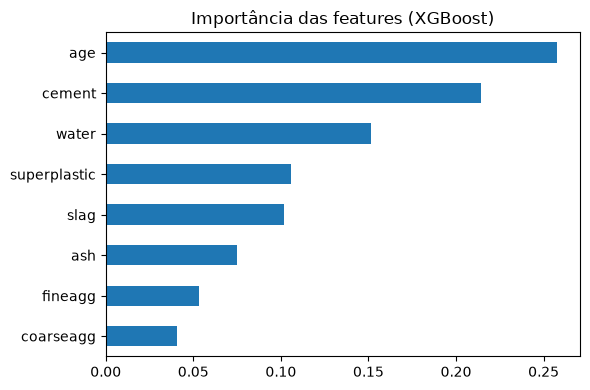

In [24]:
importances = pd.Series(final_xgb.feature_importances_, index=df.drop(columns=[TARGET]).columns)
importances.sort_values().plot(kind="barh", figsize=(6, 4), title="Importância das features (XGBoost)")
plt.tight_layout()
plt.show()

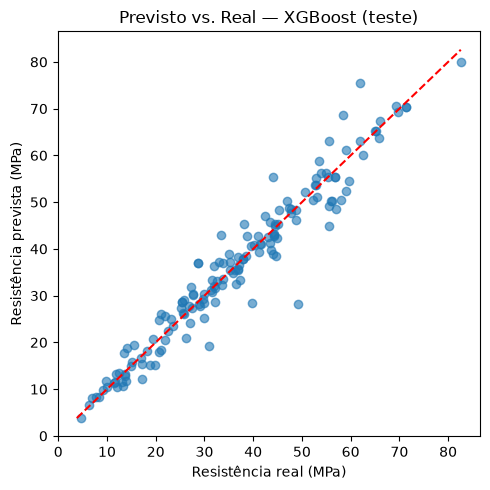

In [25]:
# Gráfico Previsto vs. Real, no mesmo estilo do que fizemos pra MLP
plt.figure(figsize=(5, 5))
plt.scatter(y_test, xgb_test_preds, alpha=0.6)
lims = [min(y_test.min(), xgb_test_preds.min()), max(y_test.max(), xgb_test_preds.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Resistência real (MPa)")
plt.ylabel("Resistência prevista (MPa)")
plt.title("Previsto vs. Real — XGBoost (teste)")
plt.tight_layout()
plt.show()

O XGBoost superou a MLP em todas as métricas (RMSE 4.12 vs. ~4.5–5.4 MPa; MAE 2.71 vs. ~3.6–3.85; R² 0.939 vs. ~0.89–0.91). Esse resultado é consistente com a literatura de aprendizado de máquina aplicada a dados tabulares de porte pequeno/médio, onde métodos de *gradient boosting* costumam superar redes neurais, o que não indica um problema com a MLP, mas uma característica esperada desse tipo de dado. Inclusive, o próprio professor destacou isto na análise da proposta de projeto.

A análise de importância de variáveis do XGBoost mostrou `age` e `cement` como as features mais relevantes, seguidas por `water` e `superplastic`, enquanto `fineagg` e `coarseagg` ficaram entre as menos importantes. Isso é coerente com o que já havia aparecido na matriz de correlação apresentada no início do notebook: `age` tinha correlação linear relativamente fraca com a resistência (0.33, contra 0.50 de `cement`), porém aparece à frente do cimento na importância calculada pelo XGBoost. A explicação é que a cura do concreto segue uma relação não linear com o tempo, ganho de resistência rápido nas primeiras idades, com desaceleração posterior, algo que a correlação de Pearson, por medir apenas relação linear, tende a subestimar. Modelos baseados em árvores capturam esse tipo de não linearidade sem exigir transformação manual da variável, o que explica a diferença de ranking entre a correlação simples e a importância do modelo.

Esse mesmo padrão, `age` como variável mais influente, à frente de `cement`, com `water` e `fly ash`/`coarse aggregate` em posição intermediária e `superplasticizer`/`fine aggregate` entre as menos relevantes, foi reportado em estudos que aplicaram SHAP sobre o mesmo dataset (1030 amostras, 8 variáveis) usando CatBoost e XGBoost (Kaggle/UCI Concrete Compressive Strength; ver [Al-Shamiri et al., 2024, Scientific Reports](https://www.nature.com/articles/s41598-024-66957-3); e [Naser & Alavi, 2023, Scientific Reports](https://www.nature.com/articles/s41598-023-47169-7)).

A menor relevância dos agregados graúdo e miúdo também tem respaldo na literatura da ciência dos materiais: em concreto convencional, o agregado atua principalmente como material de preenchimento ("filler"), e a resistência à compressão é controlada majoritariamente pela resistência da pasta de cimento e pela qualidade da ligação entre pasta e agregado, não pela resistência intrínseca do agregado em si ([ScienceDirect Topics, Aggregate Concrete](https://www.sciencedirect.com/topics/engineering/aggregate-concrete)). Isso explica por que essas variáveis contribuem menos para a previsão do modelo do que o teor de cimento, água e idade de cura.

Esse tópico será mais desenvolvido no documento final.

## 4. SHAP

In [ ]:
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test)

feature_names = df.drop(columns=[TARGET]).columns
X_test_df = pd.DataFrame(X_test, columns=feature_names)

C:\Users\andre\AppData\Local\Temp\ipykernel_11364\3456836184.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)


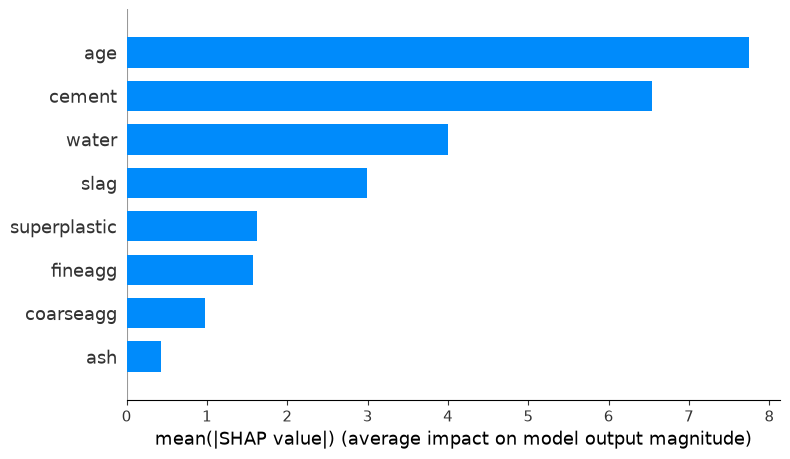

In [ ]:
shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

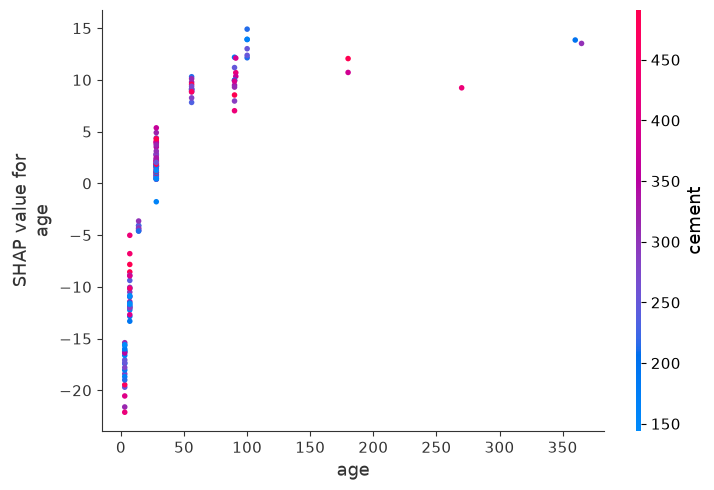

In [ ]:
shap.dependence_plot("age", shap_values, X_test_df, show=False)
plt.tight_layout()
plt.show()

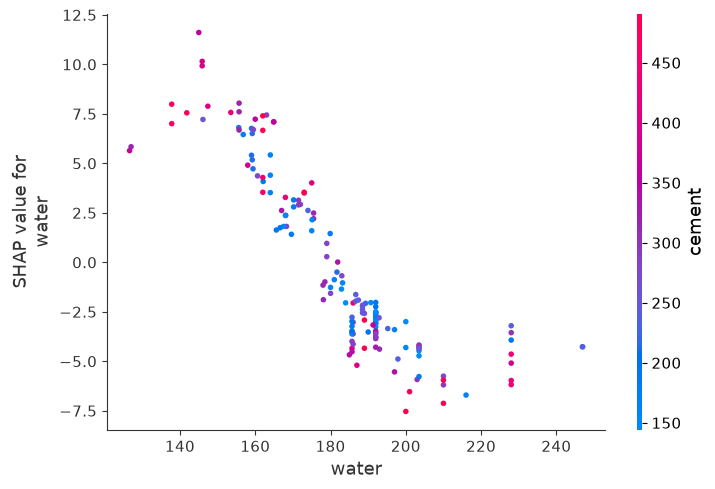

In [ ]:
shap.dependence_plot("water", shap_values, X_test_df, show=False)
plt.tight_layout()
plt.show()

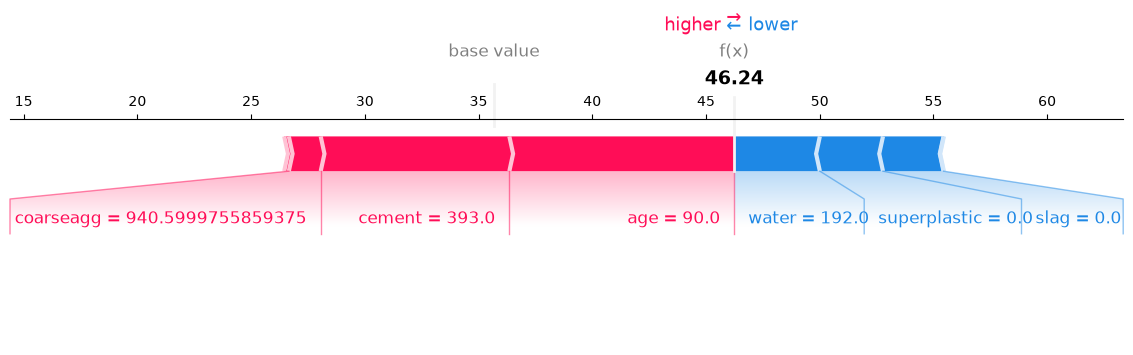

In [40]:
shap.force_plot(
    explainer.expected_value, shap_values[67], X_test_df.iloc[67],
    matplotlib=True, show=False
    , figsize=(12, 4)
)

plt.tight_layout()
plt.show()

Para complementar a análise de importância de variáveis do XGBoost, apliquei SHAP (SHapley Additive exPlanations), uma técnica baseada em teoria dos jogos que atribui a cada variável sua contribuição real para cada previsão individual, agregando esses valores depois para obter uma medida de importância mais consistente do que o critério de ganho usado internamente pelas árvores. Além disso, o SHAP também foi uma recomendação do professor Rodrigo.

O ranking geral obtido confirma o que já havia aparecido na análise anterior, com `age` e `cement` como as variáveis mais influentes, seguidas por `water`. Houve, no entanto, uma pequena reordenação nas posições intermediárias, com `slag` subindo no ranking e `ash` caindo para a última posição. Essa diferença é esperada, já que a importância padrão do XGBoost mede o quanto cada variável reduz o erro nos splits das árvores, enquanto o SHAP mede a contribuição real de cada variável em cada amostra do teste, o que produz uma medida mais robusta e teoricamente justificada.

O gráfico de dependência de `age` traz a confirmação empírica da hipótese levantada na discussão do início do notebook. Para idades baixas (menores que 10 a 15 dias) o valor de SHAP é fortemente negativo, chegando a cerca de 20 MPa abaixo do esperado, e sobe rapidamente até estabilizar em um platô positivo por volta de 90 a 100 dias, permanecendo praticamente constante até os 360 dias observados no dataset. Esse comportamento reproduz a curva de cura clássica do concreto, com ganho rápido de resistência nas primeiras semanas seguido de estabilização, e mostra por que a correlação linear simples subestimava a importância dessa variável: o modelo captura essa não linearidade sem qualquer transformação manual da feature.

O gráfico de dependência de `water` mostra uma relação negativa e aproximadamente monotônica com o valor de SHAP, com o efeito mais acentuado na faixa intermediária de valores (entre 160 e 200) e achatando nos extremos. Esse padrão é consistente com o princípio clássico da razão água/cimento, segundo o qual o excesso de água na mistura reduz a resistência final do concreto.

Por fim, o force plot de uma amostra individual do conjunto de teste ilustra como o modelo combina essas contribuições em um caso concreto. Nessa amostra, a previsão ficou acima da média geral do modelo (f(x) = 46.24 MPa, contra um valor base próximo de 37 MPa), puxada principalmente por uma idade de cura elevada (90 dias), um teor de cimento relativamente alto (393) e um valor elevado de agregado graúdo (aproximadamente 941). Em contrapartida, o teor de água (192) contribuiu para reduzir a previsão, enquanto a ausência de superplastificante e de escória de alto forno nessa mistura também empurrou o valor final ligeiramente para baixo. O resultado é coerente com os padrões já discutidos, já que cimento e idade em níveis altos favorecem a resistência, enquanto água em excesso tende a reduzi-la.

Em conjunto, esses resultados reforçam que o modelo não apenas apresenta bom desempenho preditivo, mas também captura relações fisicamente coerentes com o comportamento conhecido do concreto, o que dá suporte à conclusão de que o XGBoost é adequado tanto para prever quanto para explicar a resistência à compressão neste conjunto de dados.

## 5. Algoritmo Genético (GA)

Por fim, chegando na última etapa proposta pelo projeto, acredito que o GA é a parte mais interessante, pois ela abre portas para que seja possível predizermos proporções sem precisamos fazer experimentalmente. Como é possivel ver pelos dados, a etapa de "cura" leva muitos dias, e a partir de 100 dias que ficam valores de compressibilidade bom. Logo, prever qual seria a possível resistência é extremamente interessante. Com isso em mente, podemos fixar o tempo de cura do material em 30 dias, essa escolha é interessante tanto pensando na escala de experimentação, quanto para que o GA não sempre utilize o maior valor possível (como vimos nos tópicos anteriores, o tempo apresenta um carater crescente somente nos 100 primeiros dias).

### 5.1 Primeiro Algoritmo Genético

In [62]:
feature_names = df.drop(columns=[TARGET]).columns.tolist()
bounds = {
    col: (df[col].min(), df[col].max())
    for col in feature_names
}

AGE_FIXED = 30.0  # dias, idade padrão de ensaio
optimizable_features = [c for c in feature_names if c != "age"]

print(bounds)

{'cement': (np.float64(102.0), np.float64(540.0)), 'slag': (np.float64(0.0), np.float64(359.4)), 'ash': (np.float64(0.0), np.float64(200.1)), 'water': (np.float64(121.8), np.float64(247.0)), 'superplastic': (np.float64(0.0), np.float64(32.2)), 'coarseagg': (np.float64(801.0), np.float64(1145.0)), 'fineagg': (np.float64(594.0), np.float64(992.6)), 'age': (np.int64(1), np.int64(365))}


In [63]:
def predict_strength(mixture_dict):
    """Recebe um dict {feature: valor} (sem 'age'), monta a linha completa e prevê via XGBoost."""
    row = {**mixture_dict, "age": AGE_FIXED}
    X_row = pd.DataFrame([row])[feature_names]  # garante a ordem certa das colunas
    return final_xgb.predict(X_row)[0]

In [64]:
# --- Algoritmo Genético (implementação simples, sem dependência externa) ---

POP_SIZE = 60
N_GENERATIONS = 80
MUTATION_RATE = 0.2
MUTATION_STRENGTH = 0.1   # fração do range da feature usada como desvio da mutação
ELITE_SIZE = 4
TOURNAMENT_SIZE = 3

rng = np.random.default_rng(SEED)

def random_individual():
    return {f: rng.uniform(bounds[f][0], bounds[f][1]) for f in optimizable_features}

def fitness(individual):
    return predict_strength(individual)

def tournament_selection(population, fitnesses):
    idx = rng.choice(len(population), TOURNAMENT_SIZE, replace=False)
    best_idx = idx[np.argmax(fitnesses[idx])]
    return population[best_idx]

def crossover(parent1, parent2):
    alpha = rng.uniform(0.3, 0.7)
    child = {f: alpha * parent1[f] + (1 - alpha) * parent2[f] for f in optimizable_features}
    return child

def mutate(individual):
    child = dict(individual)
    for f in optimizable_features:
        if rng.random() < MUTATION_RATE:
            lo, hi = bounds[f]
            noise = rng.normal(0, MUTATION_STRENGTH * (hi - lo))
            child[f] = float(np.clip(child[f] + noise, lo, hi))
    return child

In [65]:
population = [random_individual() for _ in range(POP_SIZE)]
history = []

for gen in range(N_GENERATIONS):
    fitnesses = np.array([fitness(ind) for ind in population])

    best_idx = np.argsort(fitnesses)[::-1]
    elites = [population[i] for i in best_idx[:ELITE_SIZE]]

    new_population = list(elites)
    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, fitnesses)
        p2 = tournament_selection(population, fitnesses)
        child = mutate(crossover(p1, p2))
        new_population.append(child)

    population = new_population
    history.append(fitnesses.max())

    if gen % 10 == 0 or gen == N_GENERATIONS - 1:
        print(f"Geração {gen:3d} | melhor resistência prevista: {fitnesses.max():.2f} MPa")

Geração   0 | melhor resistência prevista: 74.00 MPa
Geração  10 | melhor resistência prevista: 86.85 MPa
Geração  20 | melhor resistência prevista: 88.32 MPa
Geração  30 | melhor resistência prevista: 89.03 MPa
Geração  40 | melhor resistência prevista: 89.03 MPa
Geração  50 | melhor resistência prevista: 89.03 MPa
Geração  60 | melhor resistência prevista: 89.34 MPa
Geração  70 | melhor resistência prevista: 89.34 MPa
Geração  79 | melhor resistência prevista: 89.34 MPa


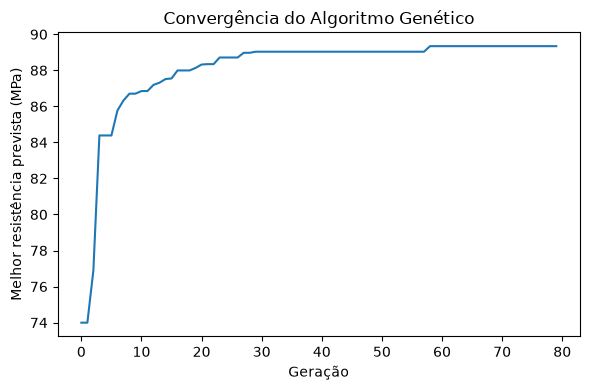

In [66]:
plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("Geração")
plt.ylabel("Melhor resistência prevista (MPa)")
plt.title("Convergência do Algoritmo Genético")
plt.tight_layout()
plt.show()

In [67]:
final_fitnesses = np.array([fitness(ind) for ind in population])
best_individual = population[np.argmax(final_fitnesses)]
best_strength = final_fitnesses.max()

print(f"Melhor mistura encontrada (idade fixa em {AGE_FIXED:.0f} dias):\n")
for f in optimizable_features:
    print(f"  {f:14s}: {best_individual[f]:.1f}")
print(f"\nResistência prevista: {best_strength:.2f} MPa")

print(f"\nPara referência, a maior resistência observada no dataset foi: {df[TARGET].max():.2f} MPa")

Melhor mistura encontrada (idade fixa em 30 dias):

  cement        : 459.9
  slag          : 289.4
  ash           : 132.1
  water         : 146.1
  superplastic  : 10.4
  coarseagg     : 815.1
  fineagg       : 750.9

Resistência prevista: 89.34 MPa

Para referência, a maior resistência observada no dataset foi: 82.60 MPa


### 5.2 Análise Melhor Candidato x Estatística

In [68]:
best_row = pd.Series(best_individual)
stats = df[optimizable_features].describe().T[["mean", "std", "min", "max"]]
stats["ga_value"] = best_row
stats["percentil_no_dataset"] = [
    (df[f] <= best_individual[f]).mean() * 100 for f in optimizable_features
]
stats

,mean,std,min,max,ga_value,percentil_no_dataset
cement,281.167864,104.506364,102.0,540.0,459.873056,92.815534
slag,73.895825,86.279342,0.0,359.4,289.440546,98.834951
ash,54.188350,63.997004,0.0,200.1,132.105248,87.378641
water,181.567282,21.354219,121.8,247.0,146.063395,4.854369
superplastic,6.204660,5.973841,0.0,32.2,10.447315,76.699029
coarseagg,972.918932,77.753954,801.0,1145.0,815.138103,0.970874
fineagg,773.580485,80.175980,594.0,992.6,750.893942,32.330097


In [69]:
# O GA otimiza cada variável dentro do seu range individual, mas não garante que a
# COMBINAÇÃO das três fontes de material cimentício (cement + slag + ash) já foi
# observada junta no dataset original.
df["binder_total"] = df["cement"] + df["slag"] + df["ash"]
ga_binder_total = best_individual["cement"] + best_individual["slag"] + best_individual["ash"]

print(f"Material cimentício total sugerido pelo GA: {ga_binder_total:.1f}")
print(f"Máximo de material cimentício total observado no dataset: {df['binder_total'].max():.1f}")
print(f"Percentil desse total no dataset: {(df['binder_total'] <= ga_binder_total).mean()*100:.1f}%")

Material cimentício total sugerido pelo GA: 881.4
Máximo de material cimentício total observado no dataset: 640.0
Percentil desse total no dataset: 100.0%


In [70]:
# Razão água / material cimentício (proxy da razão água/cimento clássica) — mais
# informativa do que olhar 'water' isolado, porque o que importa é a proporção
df["wb_ratio"] = df["water"] / df["binder_total"]
ga_wb_ratio = best_individual["water"] / ga_binder_total

print(f"Razão água/binder sugerida pelo GA: {ga_wb_ratio:.3f}")
print(f"Razão água/binder mínima observada no dataset: {df['wb_ratio'].min():.3f}")
print(f"Razão água/binder média observada no dataset: {df['wb_ratio'].mean():.3f}")

Razão água/binder sugerida pelo GA: 0.166
Razão água/binder mínima observada no dataset: 0.235
Razão água/binder média observada no dataset: 0.469



A busca livre do GA encontrou uma composição que, segundo o XGBoost, atingiria 89.34 MPa de resistência à compressão, superando o valor máximo observado no dataset original (82.60 MPa). Antes de aceitar esse número como uma formulação candidata, no entanto, é necessário verificar se essa composição está dentro da região do espaço de variáveis onde o modelo realmente tem suporte de dados de treino, e não apenas dentro dos limites individuais de cada variável.

Ao comparar a mistura encontrada com as estatísticas do dataset, dois indicadores compostos revelam uma extrapolação clara. O total de material cimentício sugerido pelo GA, somando cimento, escória e cinza volante, chega a 881.4 kg/m³, valor superior ao máximo observado em qualquer uma das 1030 amostras originais, que é de 640.0 kg/m³. Da mesma forma, a razão entre água e material cimentício sugerida pelo GA é de 0.166, abaixo do mínimo histórico observado no dataset, que é 0.235. Em ambos os casos, o modelo está sendo solicitado a prever fora da região onde existe qualquer exemplo real de referência, mesmo que cada variável isolada, olhada individualmente, esteja dentro do intervalo observado.

O motivo dessa extrapolação fica claro ao observar o percentil de cada variável na mistura sugerida em relação à distribuição do dataset. Cimento, escória e cinza volante aparecem simultaneamente próximos do teto de suas respectivas distribuições, em 92.8%, 98.8% e 87.4% respectivamente. Isso é estatisticamente incomum porque, em formulações reais de concreto, esses três materiais cimentícios costumam ser parcialmente substitutos entre si: aumentar a proporção de escória ou cinza volante normalmente vem acompanhado de uma redução no teor de cimento Portland, e não de um acréscimo simultâneo dos três. Ao mesmo tempo, a água ficou no percentil 4.85%, próxima do mínimo histórico, e o agregado graúdo no percentil 0.97%, praticamente o menor valor já observado. A mistura ótima encontrada combina, portanto, quatro extremos de distribuição ao mesmo tempo, o que é diferente de cada extremo ocorrer isoladamente em alguma amostra real do dataset.

Esse resultado ilustra uma limitação importante de otimização guiada exclusivamente por um modelo estatístico treinado sobre dados observacionais. O algoritmo genético respeitou os limites individuais de cada variável, definidos pelo mínimo e máximo observados no dataset, mas não tinha nenhuma noção de que certas combinações de variáveis são fisicamente ou tecnologicamente inviáveis, mesmo quando cada variável isolada é plausível. Sem restrições adicionais vindas do conhecimento de domínio, como um teto para o total de material cimentício ou um piso para a razão água/binder praticável, a busca converge para uma região do espaço de composições onde o modelo está extrapolando sem qualquer apoio de dado real, e a previsão de 89.34 MPa deve ser interpretada com cautela, não como uma formulação recomendada.

Diante disso, a próxima etapa é repetir a otimização impondo essas duas restrições, limitando o total de material cimentício ao teto observado no dataset e a razão água/binder ao mínimo observado. O objetivo não é apenas obter um número de resistência mais conservador, mas verificar se, ao restringir a busca à região onde o XGBoost realmente aprendeu um padrão a partir de dados reais, o modelo converge para uma composição que reflita relações fisicamente coerentes, como a importância de cimento e idade de cura já discutida na análise de SHAP, em vez de uma combinação estatisticamente artificial. Se isso se confirmar, o resultado reforça que o Gradient Boosting não apenas apresentou o melhor desempenho preditivo entre os modelos testados, mas também aprendeu um padrão consistente com o comportamento físico conhecido do concreto, e que os problemas encontrados na busca livre são uma limitação do processo de otimização, não do modelo em si.

### 5.3 GA Restrito

In [71]:
CEMENTITIOUS_MAX = df["binder_total"].max()   # 640.0
WB_RATIO_MIN = df["wb_ratio"].min()            # 0.235

def repair_individual(individual):
    """Projeta o indivíduo de volta pra região plausível, caso ele viole as restrições."""
    ind = dict(individual)

    binder_total = ind["cement"] + ind["slag"] + ind["ash"]
    if binder_total > CEMENTITIOUS_MAX:
        scale = CEMENTITIOUS_MAX / binder_total
        ind["cement"] *= scale
        ind["slag"] *= scale
        ind["ash"] *= scale
        binder_total = CEMENTITIOUS_MAX

    min_water = WB_RATIO_MIN * binder_total
    if ind["water"] < min_water:
        ind["water"] = min_water

    # Reaplica os limites originais do dataset após os ajustes acima
    for f in optimizable_features:
        lo, hi = bounds[f]
        ind[f] = float(np.clip(ind[f], lo, hi))

    return ind

In [72]:
def fitness_constrained(individual):
    repaired = repair_individual(individual)
    return predict_strength(repaired)

In [73]:
population = [repair_individual(random_individual()) for _ in range(POP_SIZE)]
history_constrained = []

for gen in range(N_GENERATIONS):
    fitnesses = np.array([fitness_constrained(ind) for ind in population])

    best_idx = np.argsort(fitnesses)[::-1]
    elites = [population[i] for i in best_idx[:ELITE_SIZE]]

    new_population = list(elites)
    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population, fitnesses)
        p2 = tournament_selection(population, fitnesses)
        child = repair_individual(mutate(crossover(p1, p2)))
        new_population.append(child)

    population = new_population
    history_constrained.append(fitnesses.max())

    if gen % 10 == 0 or gen == N_GENERATIONS - 1:
        print(f"Geração {gen:3d} | melhor resistência prevista (restrito): {fitnesses.max():.2f} MPa")

Geração   0 | melhor resistência prevista (restrito): 72.19 MPa
Geração  10 | melhor resistência prevista (restrito): 79.82 MPa
Geração  20 | melhor resistência prevista (restrito): 80.46 MPa
Geração  30 | melhor resistência prevista (restrito): 82.97 MPa
Geração  40 | melhor resistência prevista (restrito): 84.14 MPa
Geração  50 | melhor resistência prevista (restrito): 84.18 MPa
Geração  60 | melhor resistência prevista (restrito): 84.18 MPa
Geração  70 | melhor resistência prevista (restrito): 84.26 MPa
Geração  79 | melhor resistência prevista (restrito): 84.26 MPa


In [74]:
final_fitnesses = np.array([fitness_constrained(ind) for ind in population])
best_individual_constrained = repair_individual(population[np.argmax(final_fitnesses)])
best_strength_constrained = final_fitnesses.max()

print(f"Melhor mistura RESTRITA (idade fixa em {AGE_FIXED:.0f} dias):\n")
for f in optimizable_features:
    print(f"  {f:14s}: {best_individual_constrained[f]:.1f}")

binder_check = sum(best_individual_constrained[f] for f in ["cement", "slag", "ash"])
wb_check = best_individual_constrained["water"] / binder_check
print(f"\nMaterial cimentício total: {binder_check:.1f} (limite: {CEMENTITIOUS_MAX:.1f})")
print(f"Razão água/binder: {wb_check:.3f} (mínimo permitido: {WB_RATIO_MIN:.3f})")
print(f"\nResistência prevista: {best_strength_constrained:.2f} MPa")
print(f"Resistência prevista (busca livre, pra comparação): {best_strength:.2f} MPa")
print(f"Máximo observado no dataset: {df[TARGET].max():.2f} MPa")

Melhor mistura RESTRITA (idade fixa em 30 dias):

  cement        : 455.5
  slag          : 164.7
  ash           : 4.7
  water         : 150.2
  superplastic  : 10.4
  coarseagg     : 1031.6
  fineagg       : 746.5

Material cimentício total: 625.0 (limite: 640.0)
Razão água/binder: 0.240 (mínimo permitido: 0.235)

Resistência prevista: 84.26 MPa
Resistência prevista (busca livre, pra comparação): 89.34 MPa
Máximo observado no dataset: 82.60 MPa


## 6. Análise dos Resultados

Ao impor as duas restrições de coerência físico-química (teto para o total de material cimentício e piso para a razão água/binder), a resistência prevista pelo GA caiu de 89.34 MPa para 84.26 MPa. A queda de aproximadamente 5 MPa representa exatamente o custo de abandonar a região de extrapolação identificada na análise anterior, e o resultado restrito é bem mais defensável: fica apenas 1.66 MPa acima do máximo observado no dataset (82.60 MPa), uma diferença pequena o suficiente para ser tratada como uma extrapolação local moderada, em vez da extrapolação severa da busca livre.

A composição encontrada também muda de forma consistente com o raciocínio da seção anterior. O material cimentício total ficou em 625.0, praticamente no limite imposto de 640.0, e a razão água/binder ficou em 0.240, muito próxima do piso permitido de 0.235. Isso indica que as duas restrições estão ativas, ou seja, o algoritmo genético continua "empurrando" a composição em direção aos extremos permitidos, mas agora dentro de uma fronteira que reflete combinações realmente observadas no dataset, e não além dela.

Dentro dessas restrições, o padrão da mistura muda de forma reveladora. A proporção entre os três materiais cimentícios deixou de ser simultaneamente máxima: o teor de escória caiu de 289.4 para 164.7 e o de cinza volante praticamente zerou, indo de 132.1 para 4.7, enquanto o cimento se manteve alto, em 455.5. Ou seja, ao ser impedido de somar os três materiais no teto ao mesmo tempo, o modelo optou por concentrar o material cimentício majoritariamente em cimento Portland puro, com pouca contribuição de escória e quase nenhuma de cinza volante. Esse comportamento é consistente com o que a análise de SHAP já havia indicado, já que o cimento apareceu como uma das variáveis mais associadas a valores altos de resistência.

O agregado graúdo também se ajustou de forma notável, subindo de 815.1, próximo do mínimo histórico, para 1031.6, um valor bem mais central na distribuição do dataset. Combinado com a manutenção de um teor moderado de superplastificante (10.4), a composição final se aproxima do perfil típico de um concreto de alto desempenho real: cimento elevado, razão água/binder baixa compensada por superplastificante para manter a trabalhabilidade, e proporções de agregado dentro da faixa normalmente utilizada, em vez dos valores extremos e simultâneos observados na busca sem restrições.

Esse resultado reforça a conclusão anterior sob uma nova perspectiva. Quando a otimização é restringida à região onde o Gradient Boosting realmente aprendeu a partir de combinações de variáveis fisicamente plausíveis, o modelo não apenas produz uma previsão de resistência mais confiável, como também converge para uma formulação que reproduz relações estruturais conhecidas do concreto de alto desempenho, como o predomínio do cimento Portland sobre materiais cimentícios suplementares e o uso de superplastificante para viabilizar razões água/binder baixas. Isso indica que o padrão aprendido pelo XGBoost é fisicamente coerente, e que a diferença entre os dois resultados do algoritmo genético reflete uma limitação do processo de otimização sem restrições de domínio, e não uma limitação do modelo preditivo em si.

In [75]:
# Composição de referência: a melhor amostra REAL do dataset (não é otimização, é o próprio dado observado)
best_real_idx = df[TARGET].idxmax()
best_real = df.loc[best_real_idx, optimizable_features]
best_real_strength = df.loc[best_real_idx, TARGET]

mixtures = {
    "Melhor do dataset": (best_real, best_real_strength),
    "GA (livre)": (pd.Series(best_individual), best_strength),
    "GA (restrito)": (pd.Series(best_individual_constrained), best_strength_constrained),
}

for name, (comp, strength) in mixtures.items():
    print(f"{name}: {strength:.2f} MPa | massa total: {comp.sum():.1f} kg/m³")

Melhor do dataset: 82.60 MPa | massa total: 2447.3 kg/m³
GA (livre): 89.34 MPa | massa total: 2604.0 kg/m³
GA (restrito): 84.26 MPa | massa total: 2563.7 kg/m³


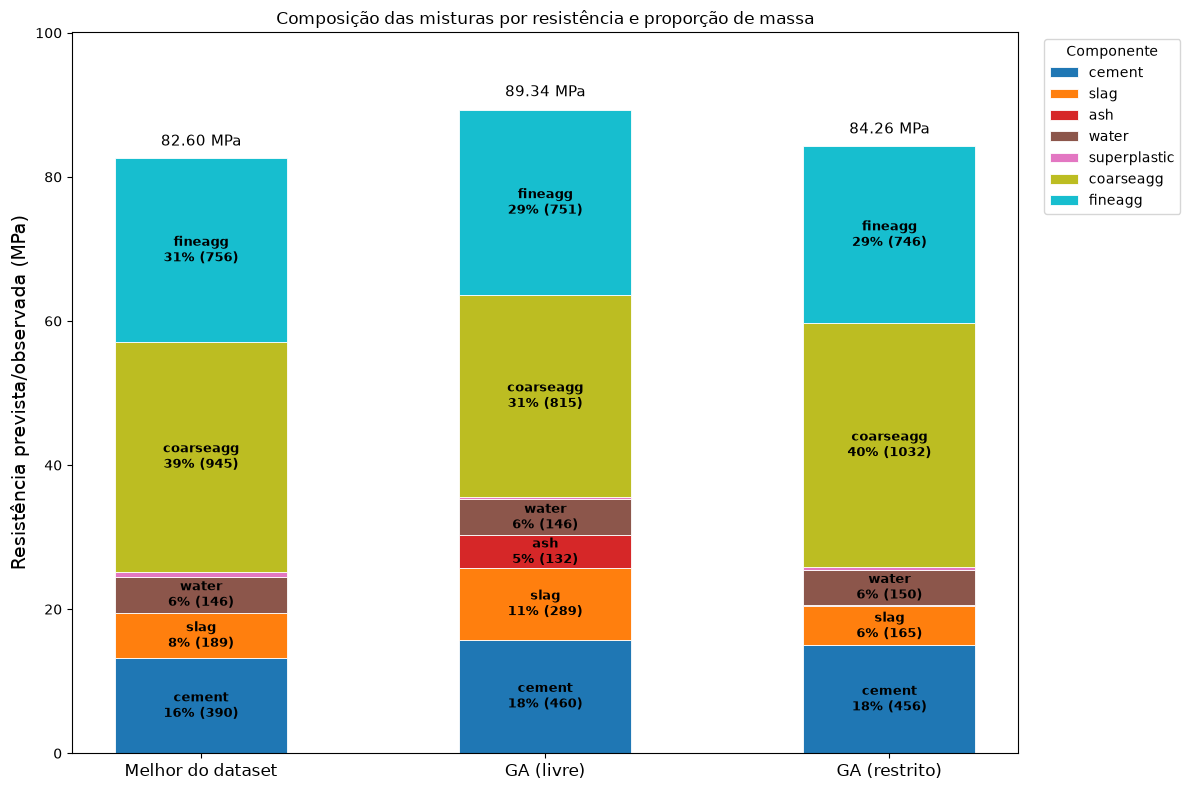

In [88]:
fig, ax = plt.subplots(figsize=(12, 8))

labels = list(mixtures.keys())
x = np.arange(len(labels))
bar_width = 0.5

colors = plt.cm.tab10(np.linspace(0, 1, len(optimizable_features)))
feature_colors = dict(zip(optimizable_features, colors))

for i, (name, (comp, strength)) in enumerate(mixtures.items()):
    total_mass = comp.sum()
    bottom = 0.0
    for feat in optimizable_features:
        pct = comp[feat] / total_mass          # fração da massa total
        seg_height = pct * strength            # a barra inteira soma ao valor de MPa

        ax.bar(x[i], seg_height, bottom=bottom, width=bar_width,
               color=feature_colors[feat], edgecolor="white", linewidth=0.6,
               label=feat if i == 0 else None)  # legenda só uma vez por feature

        # Rótulo dentro do segmento, só se ele for grande o suficiente pra caber o texto
        if seg_height > strength * 0.035:
            ax.text(x[i], bottom + seg_height / 2,
                     f"{feat}\n{pct*100:.0f}% ({comp[feat]:.0f})",
                     ha="center", va="center", fontsize=9, color="black", fontweight="bold")

        bottom += seg_height

    # Valor total de MPa no topo da barra
    ax.text(x[i], bottom + strength * 0.015, f"{strength:.2f} MPa",
             ha="center", va="bottom", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Resistência prevista/observada (MPa)", fontsize=14)
ax.set_title("Composição das misturas por resistência e proporção de massa")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Componente")
ax.set_ylim(0, max(s for _, s in mixtures.values()) * 1.12)

plt.tight_layout()
plt.show()

O gráfico consolida visualmente toda a discussão anterior. Comparando a composição das três barras, fica evidente que o GA restrito não apenas produziu uma resistência mais plausível que o GA livre, como também convergiu para proporções muito próximas às da melhor mistura real observada no dataset. O teor de cimento ficou em 18% no GA restrito contra 16% na melhor amostra real, o de escória em 6% contra 8%, o de água em 6% em ambos os casos, e o de agregado miúdo em 29% contra 31%. A maior diferença aparece no agregado graúdo, 40% no GA restrito contra 39% na amostra real, uma diferença pequena. Em outras palavras, quando restringido a uma região fisicamente plausível, o algoritmo genético não apenas evitou a extrapolação identificada anteriormente, mas essencialmente redescobriu, por conta própria e partindo de composições aleatórias, uma estrutura de proporções muito parecida com a da melhor mistura já testada fisicamente, chegando a uma resistência prevista (84.26 MPa) apenas 1.66 MPa acima da observada (82.60 MPa).

Já o GA livre revela o oposto do mesmo processo: ao não ter restrição nenhuma, ele explorou uma região distante do padrão real, introduzindo cinza volante (5%, ausente tanto na melhor amostra real quanto no GA restrito) e reduzindo a proporção de agregado graúdo de forma expressiva (31%, contra 39-40% nos outros dois casos) para abrir espaço para mais material cimentício.

Esse contraste é, na prática, uma validação indireta de que o XGBoost aprendeu um padrão consistente com o comportamento físico do concreto, e não apenas uma função capaz de interpolar bem dentro do dataset. Quando a busca é conduzida dentro dos limites de plausibilidade físico-química, o modelo guia o algoritmo genético de volta à vizinhança da melhor solução real conhecida, em vez de se afastar dela. A diferença de desempenho entre as duas versões do GA, portanto, não está no modelo em si, mas exclusivamente na ausência ou presença de restrições de domínio durante a otimização, o que

### 6.1 Comparação Final XGBoost x MLP

In [89]:
def predict_strength_mlp(mixture_dict):
    row = {**mixture_dict, "age": AGE_FIXED}
    X_row = pd.DataFrame([row])[feature_names].values.astype(np.float32)
    X_row_scaled = scaler_X.transform(X_row)

    final_model.eval()
    with torch.no_grad():
        pred_scaled = final_model(torch.tensor(X_row_scaled, dtype=torch.float32).to(device)).cpu().numpy()

    return float(scaler_y.inverse_transform(pred_scaled)[0, 0])

def fitness_mlp(individual):
    return predict_strength_mlp(individual)

In [90]:
# Mesmo GA livre (sem restrição), agora usando a MLP como avaliador
population_mlp = [random_individual() for _ in range(POP_SIZE)]
history_mlp = []

for gen in range(N_GENERATIONS):
    fitnesses = np.array([fitness_mlp(ind) for ind in population_mlp])

    best_idx = np.argsort(fitnesses)[::-1]
    elites = [population_mlp[i] for i in best_idx[:ELITE_SIZE]]

    new_population = list(elites)
    while len(new_population) < POP_SIZE:
        p1 = tournament_selection(population_mlp, fitnesses)
        p2 = tournament_selection(population_mlp, fitnesses)
        child = mutate(crossover(p1, p2))
        new_population.append(child)

    population_mlp = new_population
    history_mlp.append(fitnesses.max())

    if gen % 10 == 0 or gen == N_GENERATIONS - 1:
        print(f"Geração {gen:3d} | melhor resistência prevista (MLP): {fitnesses.max():.2f} MPa")

Geração   0 | melhor resistência prevista (MLP): 94.18 MPa
Geração  10 | melhor resistência prevista (MLP): 125.43 MPa
Geração  20 | melhor resistência prevista (MLP): 135.37 MPa
Geração  30 | melhor resistência prevista (MLP): 141.85 MPa
Geração  40 | melhor resistência prevista (MLP): 143.18 MPa
Geração  50 | melhor resistência prevista (MLP): 144.98 MPa
Geração  60 | melhor resistência prevista (MLP): 145.49 MPa
Geração  70 | melhor resistência prevista (MLP): 145.57 MPa
Geração  79 | melhor resistência prevista (MLP): 145.58 MPa


In [92]:
final_fitnesses_mlp = np.array([fitness_mlp(ind) for ind in population_mlp])
best_individual_mlp = population_mlp[np.argmax(final_fitnesses_mlp)]
best_strength_mlp = final_fitnesses_mlp.max()

print(f"Melhor mistura (GA livre, avaliado pela MLP):\n")
for f in optimizable_features:
    print(f"  {f:14s}: {best_individual_mlp[f]:.1f}")

print(f"\nResistência prevista pela MLP: {best_strength_mlp:.2f} MPa")
print(f"Resistência prevista pelo XGBoost (GA livre, pra comparação): {best_strength:.2f} MPa")
print(f"Máximo observado no dataset: {df[TARGET].max():.2f} MPa")

Melhor mistura (GA livre, avaliado pela MLP):

  cement        : 540.0
  slag          : 359.4
  ash           : 200.1
  water         : 121.8
  superplastic  : 7.9
  coarseagg     : 801.0
  fineagg       : 799.0

Resistência prevista pela MLP: 145.58 MPa
Resistência prevista pelo XGBoost (GA livre, pra comparação): 89.34 MPa
Máximo observado no dataset: 82.60 MPa


O resultado obtido ao trocar o avaliador do GA livre do XGBoost para a MLP é ainda mais revelador do que o esperado. A composição encontrada empurrou literalmente todas as sete variáveis para o limite exato observado no dataset: cimento, escória e cinza volante no valor máximo histórico, e água e agregado graúdo no valor mínimo histórico, com superplastificante e agregado miúdo também próximos dos extremos. Diferente do GA guiado pelo XGBoost, que ainda produzia uma combinação de percentuais internos razoavelmente distribuídos, aqui o algoritmo convergiu para o canto exato do hipercubo definido pelos limites de busca. A resistência prevista chegou a 145.58 MPa, um valor 76% acima do máximo observado no dataset e 63% acima da previsão já extrapolada obtida com o XGBoost na busca livre, o que reforça que essa composição está completamente fora de qualquer região onde o modelo tem apoio de dado real.

Esse resultado ilustra uma diferença estrutural importante entre os dois tipos de modelo usados neste projeto quando expostos a entradas fora da distribuição de treino. O XGBoost é composto por árvores de decisão, cuja previsão final é essencialmente uma média de valores de resistência observados nas amostras de treino que caem na mesma folha. Isso significa que, mesmo diante de uma combinação de variáveis nunca vista, a previsão do XGBoost tende a ficar limitada a valores próximos aos extremos de resistência já observados, porque o modelo não tem mecanismo para produzir uma saída fora do intervalo de valores vistos durante o treinamento. Já a MLP é composta por camadas lineares seguidas de ativações não lineares, com uma camada de saída sem qualquer limitação de intervalo, o que permite que a rede extrapole de forma continuada e, em alguns casos, amplificada quando a entrada se afasta da região de treino, especialmente quando várias variáveis se afastam da distribuição observada ao mesmo tempo, como ocorreu aqui.

Esse achado reforça e generaliza a conclusão já discutida a respeito do GA guiado pelo XGBoost. O problema identificado não é exclusivo de um modelo específico, mas sim do processo de otimização sem restrições de domínio, aplicado sobre qualquer modelo preditivo treinado em dados observacionais. A diferença de magnitude entre os dois resultados (89.34 MPa contra 145.58 MPa) mostra, no entanto, que modelos baseados em árvores tendem a ser mais conservadores diante de extrapolação do que redes neurais, um ponto relevante para a escolha de qual modelo utilizar como avaliador em processos de otimização guiados por dados, mesmo quando os dois modelos apresentam desempenho preditivo comparável dentro da distribuição de treino, como foi o caso da comparação MLP versus XGBoost feita no início deste notebook.

# 7.1 Conclusão

Ao final deste trabalho, cabe destacar que o valor do projeto não está na complexidade do dataset utilizado, mas sim no caminho metodológico construído a partir dele. O dataset de resistência à compressão do concreto é propositalmente simples, com poucas variáveis, sem valores ausentes e já tabulado, o que foi decisivo para permitir que o foco do trabalho estivesse na comparação criteriosa entre diferentes abordagens de modelagem, e não na etapa de limpeza ou engenharia de dados. Da mesma forma, tanto a MLP quanto o XGBoost são modelos relativamente padrão dentro de suas respectivas famílias, e essa escolha foi intencional: o objetivo nunca foi buscar o modelo mais sofisticado possível, mas sim entender, de forma controlada, como e por que diferentes arquiteturas se comportam de maneira distinta diante do mesmo problema.

Seguindo as recomendações do professor, o trabalho evoluiu de um pipeline inicial de MLP com validação cruzada para uma comparação justa com um baseline de Gradient Boosting, avaliado sob as mesmas condições de split, k-fold e métricas. Essa comparação revelou o padrão amplamente documentado na literatura de que boosting tende a superar redes neurais em dados tabulares de porte pequeno, resultado que já seria suficiente para atender à proposta original. Mas o ponto que tornou a análise mais rica foi ir além da métrica de erro e investigar o que cada modelo realmente aprendeu, por meio da análise de importância de variáveis e do SHAP, confirmando que o XGBoost capturou relações fisicamente coerentes com o comportamento conhecido do concreto, como o efeito não linear da idade de cura e a influência da razão água/cimento.

A etapa de otimização com algoritmo genético, sugerida como extensão possível do projeto, acabou sendo a parte mais reveladora do trabalho. Ao usar o XGBoost como avaliador dentro de uma busca livre, ficou evidente que otimização guiada por modelo estatístico pode convergir para combinações de variáveis irrealistas mesmo respeitando os limites individuais de cada uma. A introdução de restrições vindas do conhecimento de domínio corrigiu esse comportamento e levou o algoritmo a redescobrir, partindo de composições aleatórias, uma estrutura de proporções muito próxima da melhor mistura já observada no dataset. E ao repetir esse mesmo experimento trocando o avaliador para a MLP, a diferença de comportamento entre os dois modelos diante de extrapolação ficou ainda mais clara, com a rede neural produzindo uma previsão consideravelmente mais distante da realidade do que o modelo baseado em árvores.

No conjunto, o trabalho percorre um caminho bem definido, partindo da preparação dos dados, passando pela modelagem preditiva com dois paradigmas distintos, pela interpretação do que cada modelo aprendeu e chegando à otimização guiada por esses modelos, sempre com um cuidado explícito em validar cada resultado antes de aceitá lo. Esse tipo de análise, embora aplicada aqui a um dataset simples, é diretamente generalizável a outros problemas de regressão tabular em engenharia, e acredito que essa robustez metodológica, mais do que a complexidade do dataset ou dos modelos individuais, é o principal resultado deste projeto.